<a href="https://colab.research.google.com/github/NSLCLC-18/data_science_project/blob/main/Movies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
!pip install opendatasets --upgrade --quiet
import opendatasets as od
dataset_url = 'https://www.kaggle.com/datasets/shivamb/netflix-shows'
od.download(dataset_url)

Skipping, found downloaded files in "./netflix-shows" (use force=True to force download)


In [40]:
import os

In [41]:
os.listdir('/content/netflix-shows/')

['netflix_titles.csv']

In [42]:
import pandas as pd

In [43]:
i_df = pd.read_csv('/content/netflix-shows/netflix_titles.csv')

In [44]:
i_df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [45]:
i_df.shape

(8807, 12)

In [46]:
i_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [47]:
i_df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

**DATA VISUALIZATION**



1.   Distrubution and Volume



In [48]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_253/3150313882.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




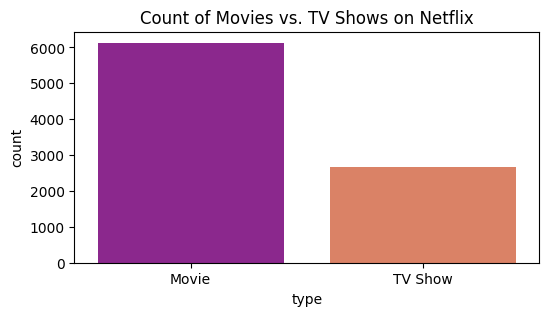

In [92]:
plt.figure(figsize=(6, 3))
sns.countplot(data=i_df, x='type', palette='plasma')
plt.title('Count of Movies vs. TV Shows on Netflix')
plt.show()

/tmp/ipykernel_253/3287237948.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




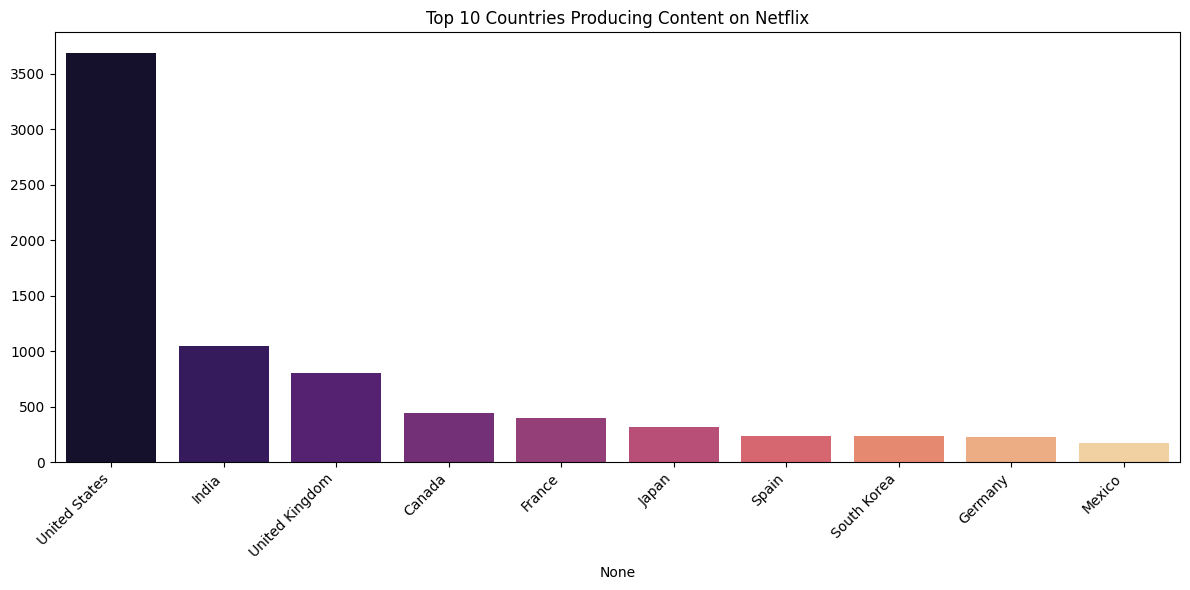

In [94]:
plt.figure(figsize=(12, 6))
sns.barplot(x=country_counts.index, y=country_counts.values, palette='magma')
plt.title('Top 10 Countries Producing Content on Netflix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

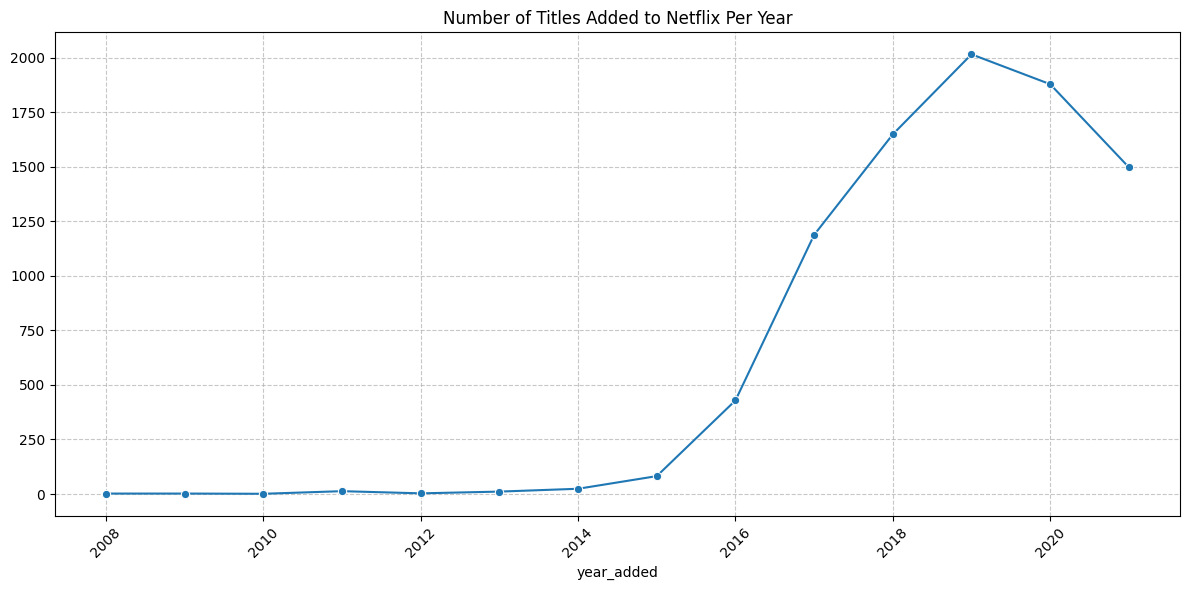

In [96]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o')
plt.title('Number of Titles Added to Netflix Per Year')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_253/1817627897.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




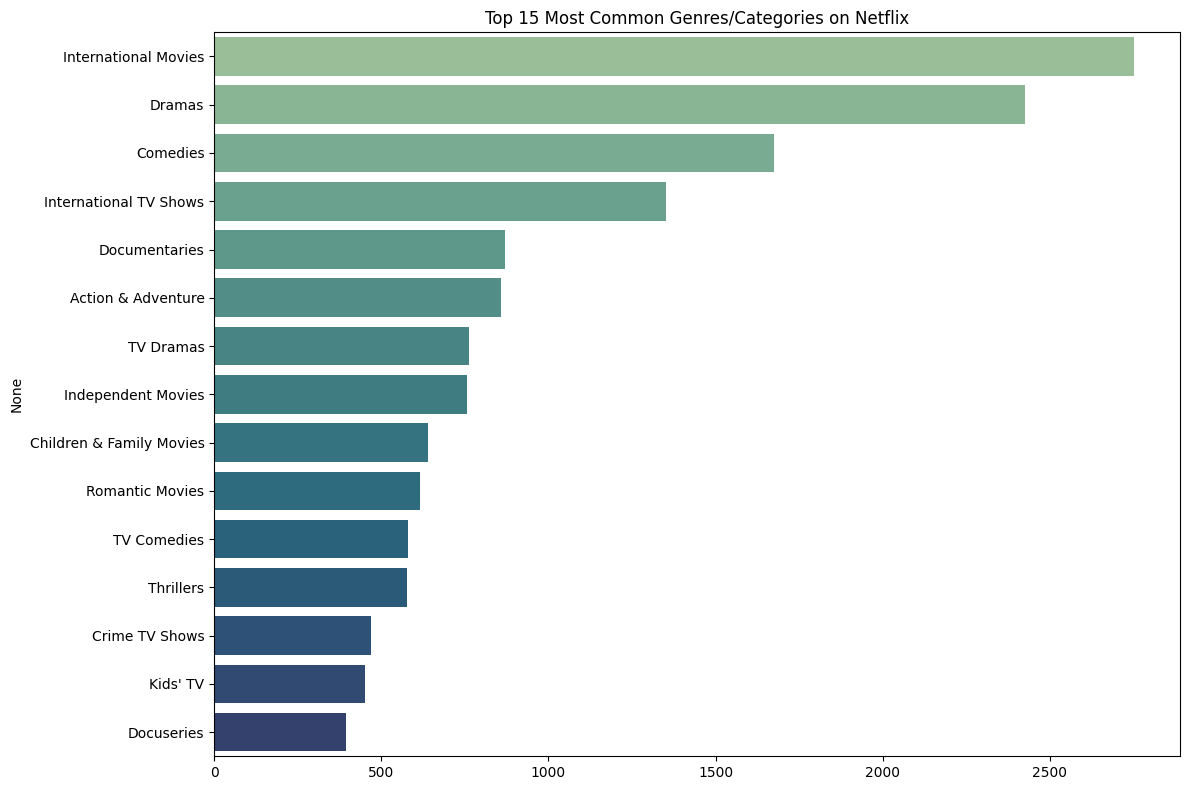

In [98]:
plt.figure(figsize=(12, 8))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='crest')
plt.title('Top 15 Most Common Genres/Categories on Netflix')
plt.tight_layout()
plt.show()

2.   Content and Genre

TREE MAP

In [66]:
pip install plotly --quiet

In [67]:
import plotly.express as px

# Prepare data for Movies
movies_df = i_df[i_df['type'] == 'Movie'].copy()
movies_genres = movies_df['listed_in'].dropna()
movies_genre_list = []
for genre_str in movies_genres:
    movies_genre_list.extend([g.strip() for g in genre_str.split(',')])
movies_genre_counts = pd.Series(movies_genre_list).value_counts().reset_index()
movies_genre_counts.columns = ['Genre', 'Count']

# Create a treemap for Movies
fig_movies = px.treemap(movies_genre_counts,
                     path=['Genre'],
                     values='Count',
                     title='Genre Distribution for Movies on Netflix',
                     color_discrete_sequence=px.colors.sequential.Plasma)
fig_movies.show()

In [68]:
# Prepare data for TV Shows
tv_shows_df = i_df[i_df['type'] == 'TV Show'].copy()
tv_shows_genres = tv_shows_df['listed_in'].dropna()
tv_shows_genre_list = []
for genre_str in tv_shows_genres:
    tv_shows_genre_list.extend([g.strip() for g in genre_str.split(',')])
tv_shows_genre_counts = pd.Series(tv_shows_genre_list).value_counts().reset_index()
tv_shows_genre_counts.columns = ['Genre', 'Count']

# Create a treemap for TV Shows
fig_tv_shows = px.treemap(tv_shows_genre_counts,
                      path=['Genre'],
                      values='Count',
                      title='Genre Distribution for TV Shows on Netflix',
                      color_discrete_sequence=px.colors.sequential.Viridis)
fig_tv_shows.show()

WORD CLOUD

In [69]:
pip install wordcloud --quiet

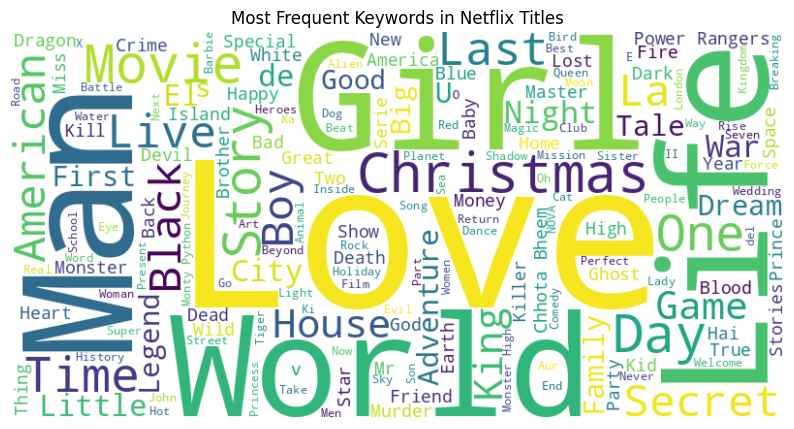

In [70]:
from wordcloud import WordCloud, STOPWORDS

# Combine all titles into a single string
text = ' '.join(i_df['title'].dropna().astype(str).tolist())

# Define stopwords to remove common words
stopwords = set(STOPWORDS)

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      stopwords=stopwords,
                      min_font_size=10).generate(text)

# Display the word cloud using matplotlib
plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Keywords in Netflix Titles')
plt.show()

3.    Ratings and Audience

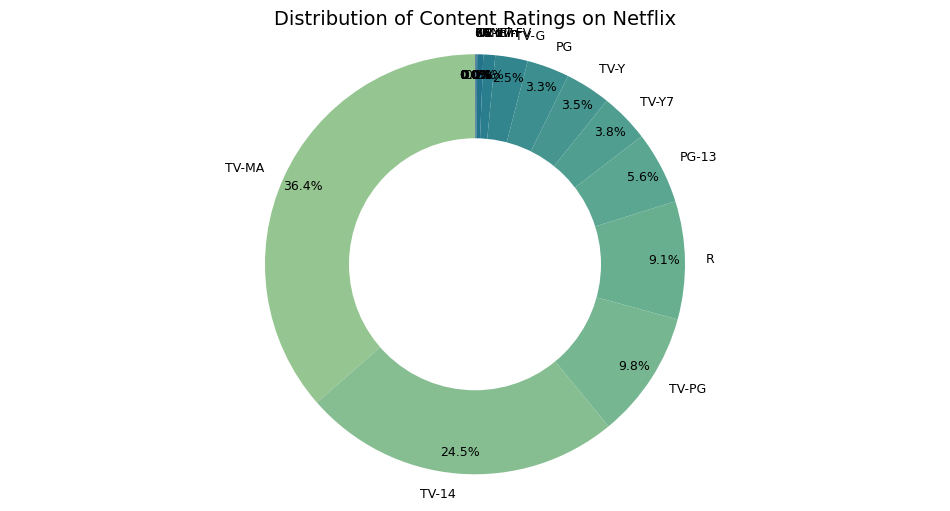

In [100]:
# Calculate the value counts for the 'rating' column
rating_counts = i_df['rating'].value_counts()

# Create a figure and axes for the plot
plt.figure(figsize=(12, 6)) # Changed figure size to be square

# Create the pie chart (outer ring of the donut)
plt.pie(rating_counts,
        labels=rating_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        pctdistance=0.90, # Adjusted pctdistance for better label placement
        colors=sns.color_palette('crest', len(rating_counts)),
        textprops={'fontsize': 9}) # Set font size for percentages

# Draw a circle in the center to make it a donut chart
centre_circle = plt.Circle((0,0), 0.60, fc='white') # Reverted center circle size for thicker donut
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('Distribution of Content Ratings on Netflix', fontsize=14) # Set font size for title
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

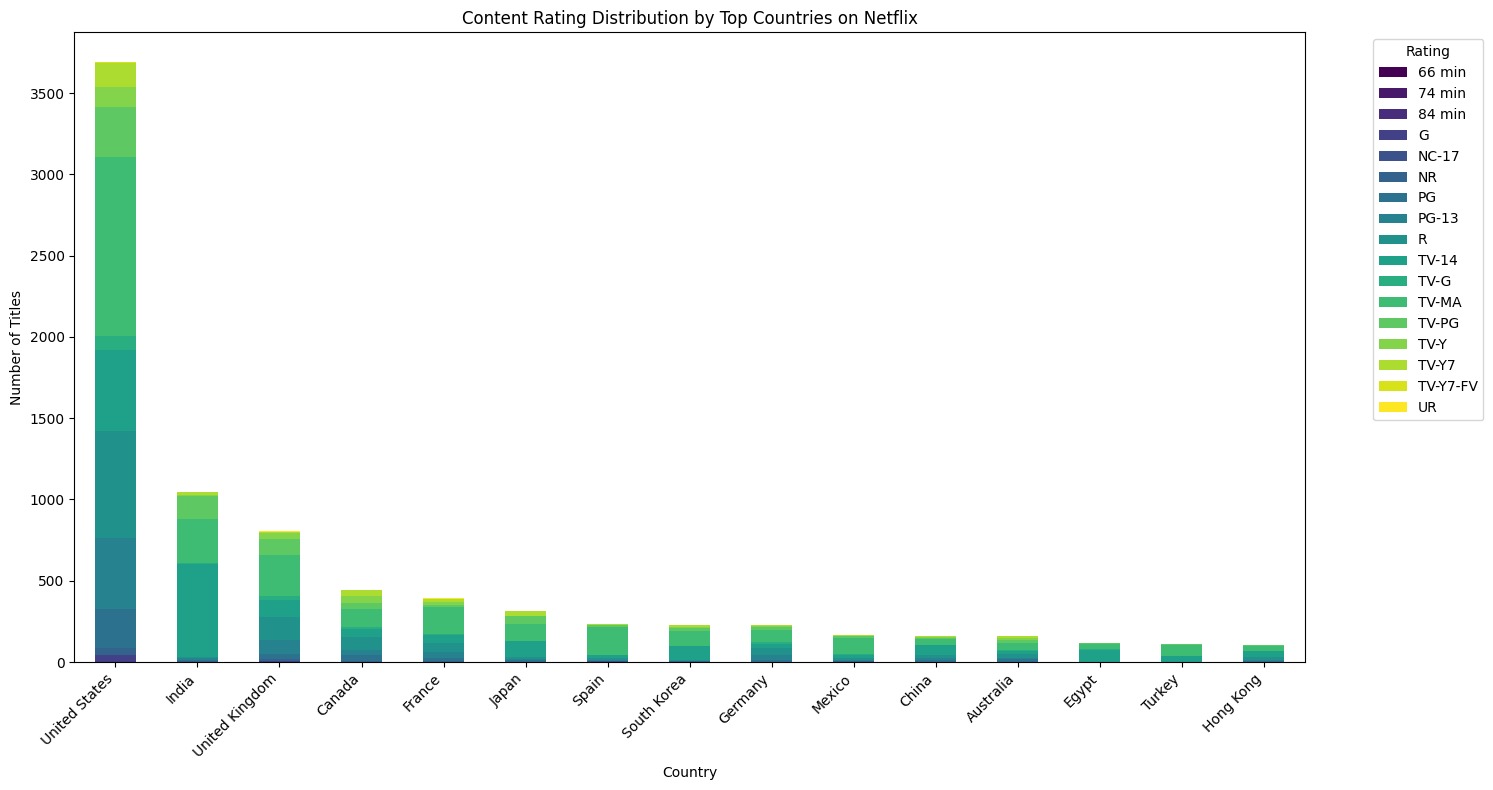

In [85]:
# Clean and expand the 'country' column for better analysis
expanded_countries_df = i_df['country'].dropna().str.split(', ').explode().reset_index(name='country_single')
# Merge with the original DataFrame to get 'rating' for each country entry
country_rating_df = i_df[['show_id', 'rating']].merge(expanded_countries_df, left_on=i_df.index, right_on='index')
# Count ratings per country
rating_by_country = country_rating_df.groupby(['country_single', 'rating']).size().unstack(fill_value=0)
# Select the top N countries for better visualization (e.g., top 10 or 15)
top_countries = rating_by_country.sum(axis=1).nlargest(15).index
rating_by_country_top = rating_by_country.loc[top_countries]
rating_by_country_top = rating_by_country_top.reindex(sorted(rating_by_country_top.columns), axis=1)
# Plot the stacked bar chart
plt.figure(figsize=(16, 8))
rating_by_country_top.plot(kind='bar', stacked=True, colormap='viridis', ax=plt.gca())
plt.title('Content Rating Distribution by Top Countries on Netflix')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

4.   Duration and Seasons

/tmp/ipykernel_253/1989081487.py:2: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.



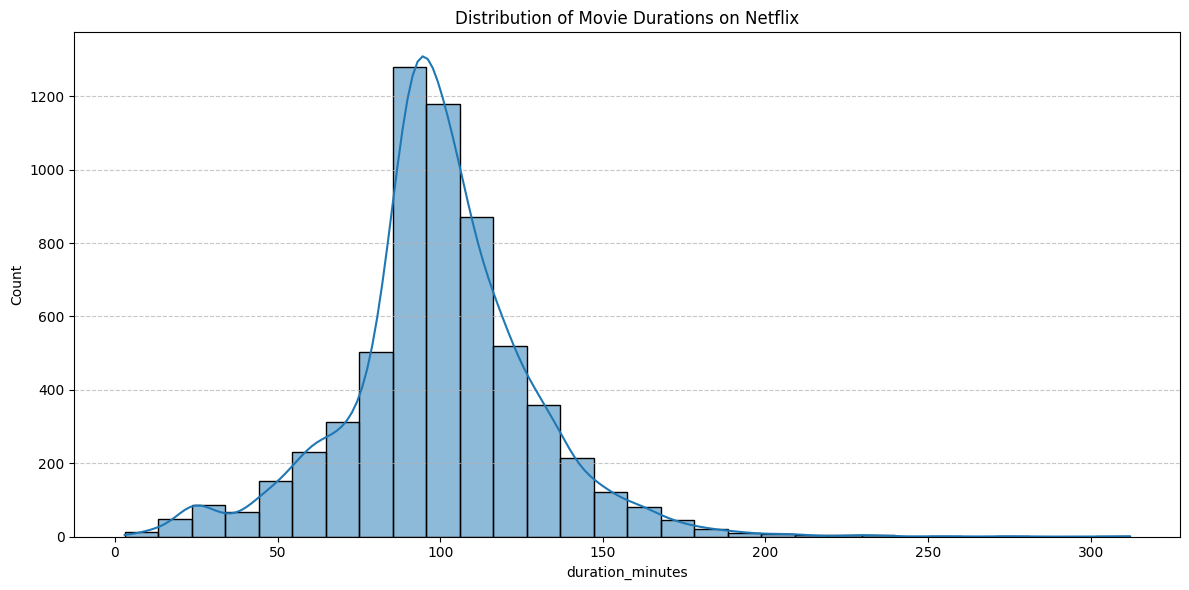

In [91]:
plt.figure(figsize=(12, 6))
sns.histplot(movie_durations['duration_minutes'], bins=30, kde=True, palette='viridis')
plt.title('Distribution of Movie Durations on Netflix')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_253/3004398398.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




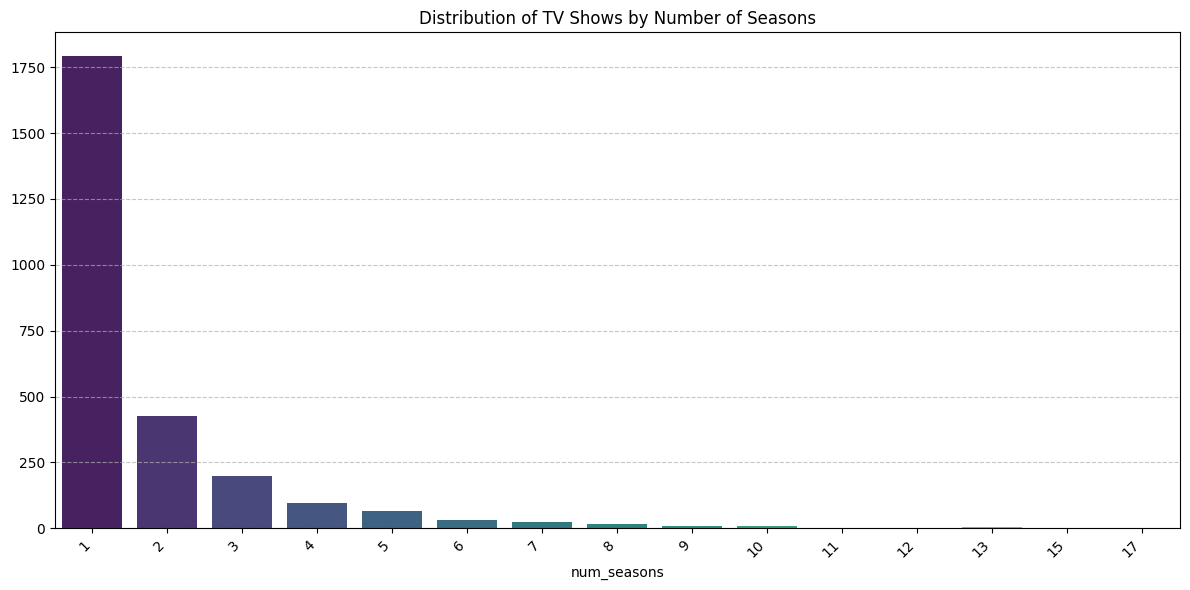

In [90]:
plt.figure(figsize=(12, 6))
sns.barplot(x=season_counts.index, y=season_counts.values, palette='viridis')
plt.title('Distribution of TV Shows by Number of Seasons')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

5.  Time Based

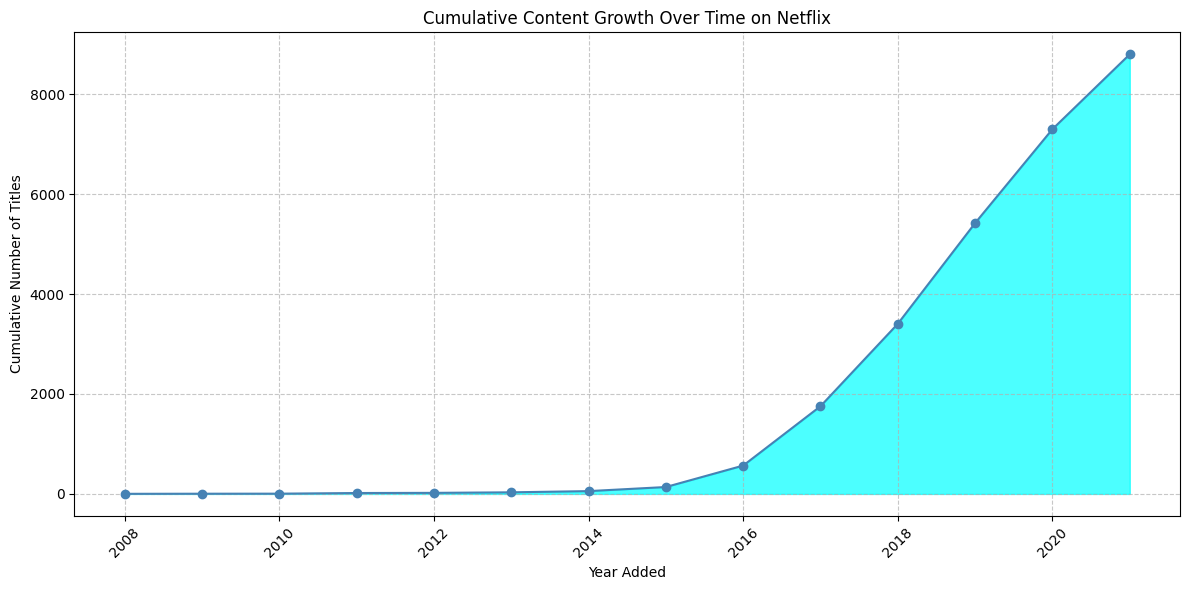

In [106]:
cumulative_titles = year_counts.cumsum()
plt.figure(figsize=(12, 6))
plt.fill_between(cumulative_titles.index, cumulative_titles.values, color='cyan', alpha=0.7)
plt.plot(cumulative_titles.index, cumulative_titles.values, color='steelblue', marker='o', linestyle='-')
plt.title('Cumulative Content Growth Over Time on Netflix')
plt.xlabel('Year Added')
plt.ylabel('Cumulative Number of Titles')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

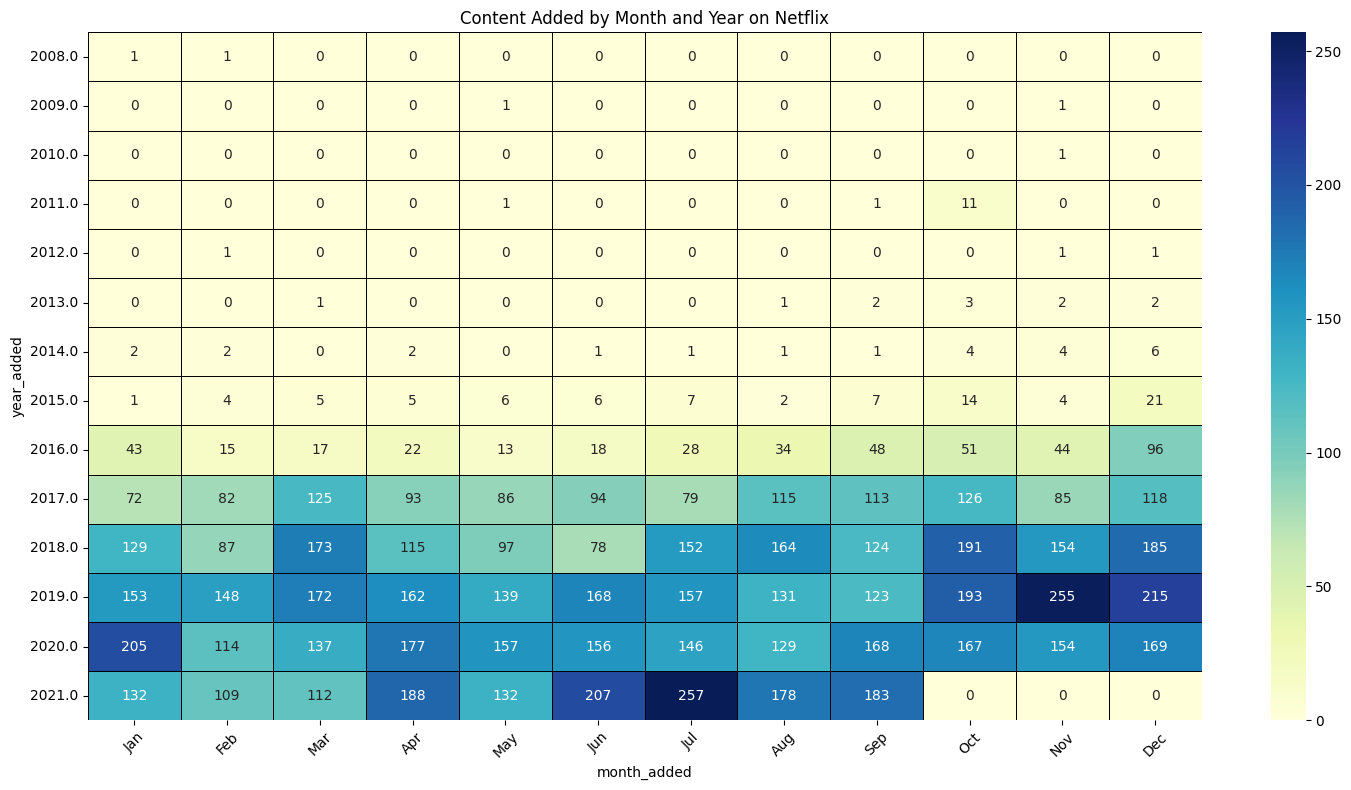

In [104]:
i_df['month_added'] = pd.to_datetime(i_df['date_added'], errors='coerce', format='mixed').dt.month
month_year_df = i_df.groupby(['year_added', 'month_added']).size().unstack(fill_value=0)
plt.figure(figsize=(15, 8))
sns.heatmap(month_year_df, cmap='YlGnBu', linewidths=0.5, linecolor='black', fmt='d', annot=True)
plt.title('Content Added by Month and Year on Netflix')
plt.xticks(np.arange(12) + 0.5, ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
plt.tight_layout()
plt.show()

6.   Poeple

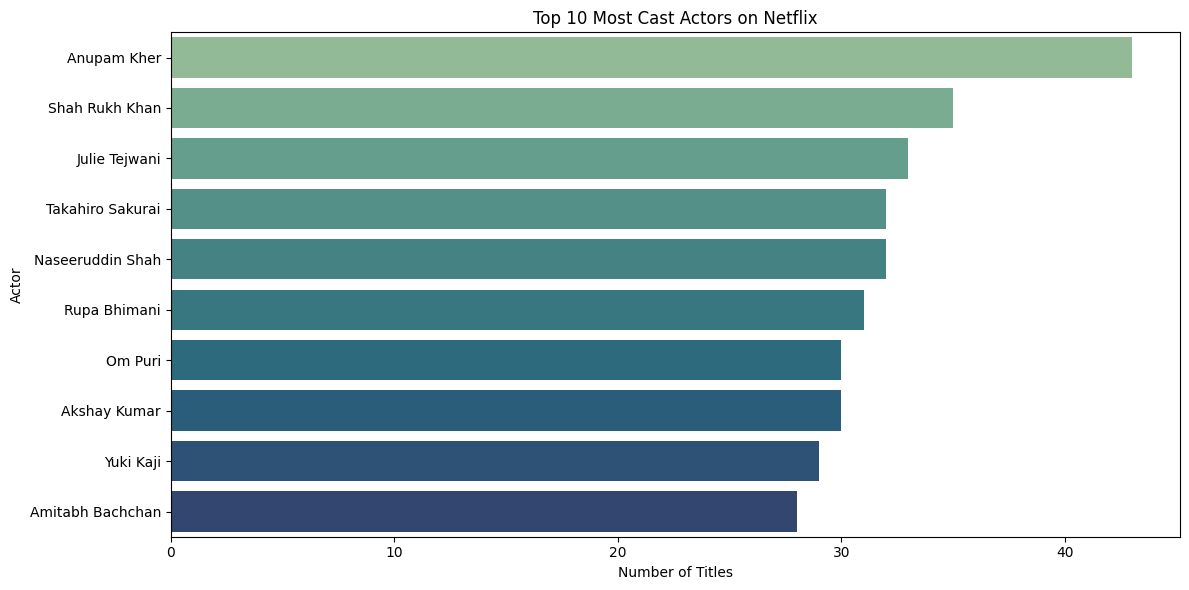

In [108]:
plt.figure(figsize=(12, 6))
sns.barplot(x=actor_counts.values, y=actor_counts.index, hue=actor_counts.index, palette='crest', legend=False)
plt.title('Top 10 Most Cast Actors on Netflix')
plt.tight_layout()
plt.show()

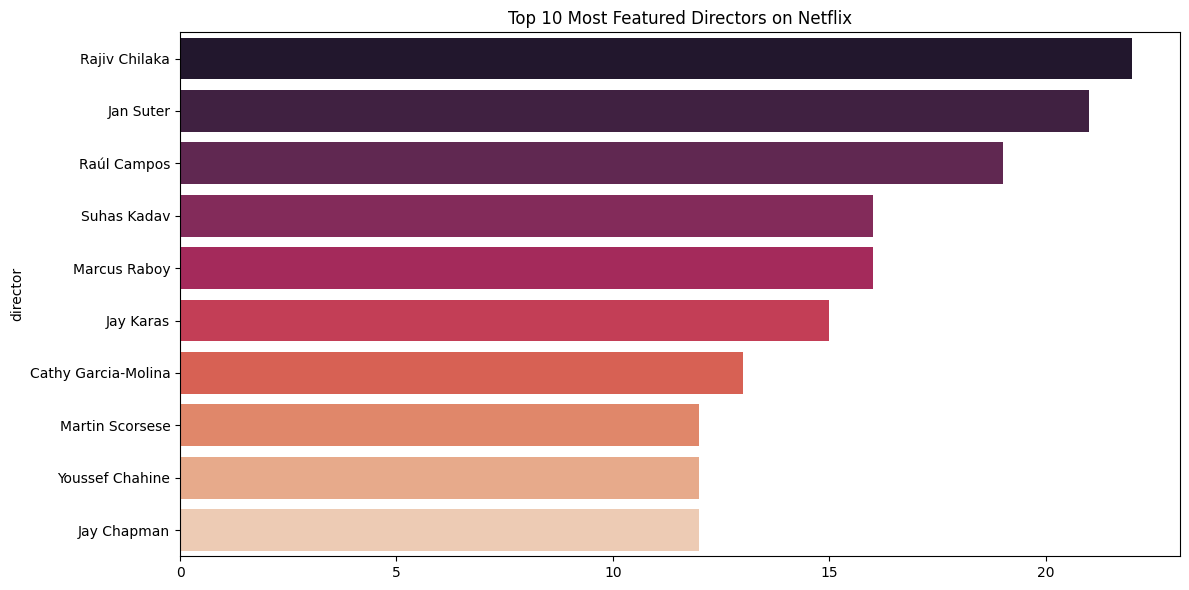

In [110]:
plt.figure(figsize=(12, 6))
sns.barplot(x=director_counts.values, y=director_counts.index, hue=director_counts.index, palette='rocket', legend=False)
plt.title('Top 10 Most Featured Directors on Netflix')
plt.tight_layout()
plt.show()